# Deep Q-Network (DQN)

* Full Name: Amirhosein Rezaei
* Student Number: 401105989

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque, namedtuple
import random
import matplotlib.pyplot as plt
import gymnasium as gym

In [2]:
# MP4 Libraries
from IPython.display import HTML
from base64 import b64encode
import cv2
import numpy as np

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Helper Functions for Video

Function to convert MP4 to displayable HTML5 video and display

In [4]:
def show_video(video_path, width=480):
    with open(video_path, "rb") as f:
        video_data = f.read()
    encoded = b64encode(video_data).decode("utf-8")
    html = f'''
        <video width="{width}" controls>
            <source src="data:video/mp4;base64,{encoded}" type="video/mp4">
        </video>
    '''
    return HTML(html)

def save_agent_video(env, agent, filename="agent_demo.mp4"):
    frames = []
    state, _ = env.reset()
    done = False

    while not done:
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        frames.append(env.render())
        state = next_state

    height, width, layers = frames[0].shape
    out = cv2.VideoWriter(
        filename, cv2.VideoWriter_fourcc(*"mp4v"), 30, (width, height)
    )
    for f in frames:
        out.write(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
    out.release()


### Checkout the Environment


In [43]:
env_temp = gym.make('LunarLander-v3', render_mode='rgb_array')
# Print the environment action space dim
print(env_temp.action_space.n)
# Print the environment observation space dim
print(env_temp.observation_space.shape[0])
# Do a random rollout and visualize the environment
class RandomAgent:
    def select_action(self, state):
        return env_temp.action_space.sample()
random_agent = RandomAgent()
random_video_path = "checkout_the_environment.mp4"
save_agent_video(env_temp, random_agent, random_video_path)
display(show_video(random_video_path, width=480))
env_temp.close()

4
8


### Replay Buffer
In DQN, the agent learns from past experiences.  
This buffer stores transitions in the form of (state, action, reward, next_state, done).

+ Your task: complete the `push` and `sample` methods.

- `push` should add a new Transition into the buffer.
- `sample` should randomly return a batch of transitions  
  (this helps break correlations and stabilize learning).

In [5]:
Transition = namedtuple('Transition', 
                        ['state', 'action', 'reward', 'next_state', 'done'])

class ReplayBuffer:
    """Stores experiences for experience replay"""
    def __init__(self, capacity: int = 100):
        self.buffer = deque(maxlen=capacity)
        self.capacity = capacity
    
    def push(self, *args):
        transition = Transition(*args)
        self.buffer.append(transition)
    
    def sample(self, batch_size: int) -> Transition:
        batch = random.sample(self.buffer, batch_size)
        return batch
    
    def __len__(self):
        return len(self.buffer)

### Q-Network

In [6]:
class QNetwork(nn.Module):
    """Simple neural network to approximate Q(s,a)"""
    def __init__(self, state_dim: int, action_dim: int):
        super(QNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
    
    def forward(self, x):
        return self.network(x)

###  Hyperparameters of the DQN Agent
These values control exploration, learning stability, and update frequency.
Feel free to experiment — small changes can significantly affect performance.

- `gamma`: discount factor  
- `epsilon`: initial exploration rate  
- `epsilon_decay`: how fast the agent shifts from exploration to exploitation  
- `batch_size`: number of samples from ReplayBuffer for each update  
- `target_update_freq`: how often the target network is updated


### Action Selection (Epsilon-Greedy)

The agent chooses between:
- exploration (random action) with probability epsilon  
- exploitation (best predicted action) otherwise


### Update Step of DQN

This is the heart of the algorithm:
1. Sample a batch from ReplayBuffer  
2. Compute predicted Q-values (current network)  
3. Compute target Q-values (target network)  
4. Calculate loss  
5. Optimize network weights  
6. Periodically update the target network

+ Your task: fill in the missing steps and complete the TODOs.
Follow the comments carefully — they guide the flow of DQN training.


In [7]:
class DQNAgent:
    """
    Simple DQN Agent
    
    Key components:
    - Q-Network: approximates Q(s,a)
    - Target Network: provides stable targets for learning
    - Replay Buffer: stores past experiences
    - Epsilon-greedy: balances exploration/exploitation
    """
    
    def __init__(self, state_dim: int, action_dim: int):
        # Hyperparameters
        self.gamma = 0.99 # Discount factor
        self.epsilon = 1.0 # Exploration rate
        self.epsilon_min = 0.01 # Minimum exploration
        self.epsilon_decay = 0.995
        self.batch_size = 64
        self.target_update_freq = 60
        self.action_dim = action_dim
        
        # Networks
        self.q_network = QNetwork(state_dim, action_dim).to(device)
        self.target_network = QNetwork(state_dim, action_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        
        # Optimizer and memory
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=0.0005)
        self.memory = ReplayBuffer(capacity=100000)
        self.steps = 0
    
    def select_action(self, state, training=True):
        """Epsilon-greedy action selection"""
        if training and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                q_values = self.q_network(state_tensor)
            return q_values.argmax().item()
    
    def store_transition(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)
    
    def update(self):
        """Update Q-network using DQN algorithm"""
        if len(self.memory) < self.batch_size:
            return None
        
        # Sample from replay buffer
        batch = self.memory.sample(self.batch_size)
        
        states = torch.FloatTensor(np.array([t.state for t in batch])).to(device)
        actions = torch.LongTensor(np.array([t.action for t in batch])).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(np.array([t.reward for t in batch])).to(device)
        next_states = torch.FloatTensor(np.array([t.next_state for t in batch])).to(device)
        dones = torch.FloatTensor(np.array([t.done for t in batch])).to(device)
        
        # ================================================================
        # DQN Update (Standard)
        # Q_target = r + γ * max_a Q_target(s', a)
        # ================================================================
        
        # Current Q values
        current_q = self.q_network(states).gather(1, actions).squeeze()
        
        # Target Q values
        with torch.no_grad():
            # Standard DQN: take max over all actions
            next_q = self.target_network(next_states).max(1)[0]
            target_q = rewards + (1 - dones) * self.gamma * next_q
        
        # Compute loss and update
        loss = nn.MSELoss()(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update target network periodically
        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
        
        # Decay epsilon
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
        return loss.item()

### Training Loop

This function orchestrates the entire training process:
- Runs episodes
- Tracks scores and losses
- Updates the agent at each timestep
- Prints progress

+ Your task: you only need to complete the parts marked with TODO.
After that, run the notebook to train your agent!


In [31]:
def train_dqn(env, agent, num_episodes=500, max_steps=1000):
    scores = []
    losses = []
    
    for episode in range(num_episodes):
        state, _ = env.reset(seed=SEED + episode)
        score = 0
        
        for step in range(max_steps):
            # Select action
            action = agent.select_action(state, training=True)
            
            # Take action
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Store and update
            agent.store_transition(state, action, reward, next_state, done)
            loss = agent.update()
            
            score += reward
            state = next_state
            
            if done:
                break
        
        scores.append(score)
        losses.append(agent.update() or 0)
        
        if (episode + 1) % 50 == 0:
            avg = np.mean(scores[-50:])
            print(f"Episode {episode+1}/{num_episodes} | Score: {score:.1f} | Avg: {avg:.1f} | ε: {agent.epsilon:.3f}")
    
    return scores, losses

TRAINING SIMPLE DQN ON LUNAR LANDER
State dim: 8, Action dim: 4

Episode 50/500 | Score: -131.9 | Avg: -179.6 | ε: 0.010
Episode 100/500 | Score: -40.8 | Avg: -182.1 | ε: 0.010
Episode 150/500 | Score: -2.7 | Avg: -41.7 | ε: 0.010
Episode 200/500 | Score: 218.9 | Avg: 130.6 | ε: 0.010
Episode 250/500 | Score: 234.2 | Avg: 197.6 | ε: 0.010
Episode 300/500 | Score: 265.0 | Avg: 207.3 | ε: 0.010
Episode 350/500 | Score: 300.3 | Avg: 213.7 | ε: 0.010
Episode 400/500 | Score: 265.1 | Avg: 205.8 | ε: 0.010
Episode 450/500 | Score: -170.5 | Avg: 182.3 | ε: 0.010
Episode 500/500 | Score: 296.0 | Avg: 219.4 | ε: 0.010


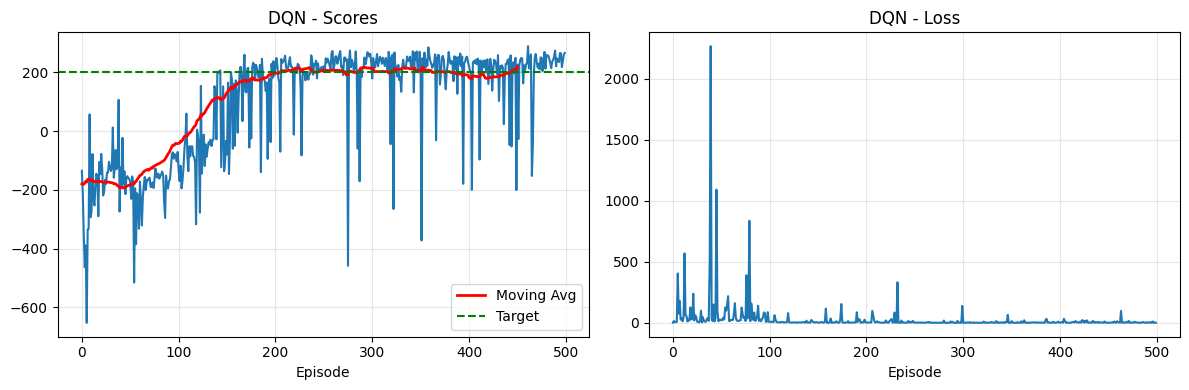


DQN Final Avg Score (last 50): 219.4


In [16]:
print("="*60)
print("TRAINING SIMPLE DQN ON LUNAR LANDER")
print("="*60)

env = gym.make('LunarLander-v3')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print(f"State dim: {state_dim}, Action dim: {action_dim}\n")

# Create agent
dqn_agent = DQNAgent(state_dim, action_dim)

# Train
dqn_scores, dqn_losses = train_dqn(env, dqn_agent, num_episodes=500, max_steps=1000)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Video
render_env = gym.make('LunarLander-v3', render_mode='rgb_array')
save_agent_video(render_env, dqn_agent, filename="dqn.mp4")
video_dqn = "dqn.mp4"

axes[0].plot(dqn_scores)
axes[0].plot(np.convolve(dqn_scores, np.ones(50)/50, mode='valid'), 'r-', linewidth=2, label='Moving Avg')
axes[0].axhline(y=200, color='g', linestyle='--', label='Target')
axes[0].set_title('DQN - Scores')
axes[0].set_xlabel('Episode')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(dqn_losses)
axes[1].set_title('DQN - Loss')
axes[1].set_xlabel('Episode')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDQN Final Avg Score (last 50): {np.mean(dqn_scores[-50:]):.1f}")

show_video(video_dqn, width=600)

# Double DQN (DDQN)

### The Problem We're Solving
Regular DQN uses the **same network** to pick the best action AND to evaluate it.
This causes **overestimation** — the agent thinks actions are better than they really are.

Think of it like grading your own test: you're probably too nice to yourself!

### The Solution: Split the Jobs
Double DQN uses **two networks**:
- **Online Network** → picks the best action (the student)
- **Target Network** → evaluates that action's value (the teacher)


### Hyperparameters
Same as DQN — no new hyperparameters needed!
- `gamma`: discount factor
- `epsilon`: exploration rate
- `epsilon_decay`: how fast we stop exploring
- `batch_size`: samples per update
- `target_update_freq`: how often to sync networks

### The Double DQN Update Step
This is where the magic happens:

1. Sample a batch from ReplayBuffer
2. Get current Q-values from **online network**
3. Find **best action** using online network  $\to a_\text{best} = \argmax Q_\text{online}(s')$
4. Get Q-values for those actions from **target network**  $\to Q_\text{target}(s', a_\text{best})$
5. Compute TD target: $y = r + \gamma \times Q_\text{target}(s', a_\text{best})$
6. Compute loss between online predictions and target
7. Optimize online network
8. Periodically update target network

In [32]:
class DDQNAgent(DQNAgent):
    """
    Double DQN extends DQN to reduce overestimation.
    
    The problem with standard DQN:
    - Uses max() which tends to overestimate Q-values
    
    Double DQN solution:
    - Use online network to SELECT the action
    - Use target network to EVALUATE the action
    
    This decouples selection from evaluation.
    """
    
    def update(self):
        """Update using Double DQN algorithm"""
        if len(self.memory) < self.batch_size:
            return None
        
        # Sample from replay buffer
        batch = self.memory.sample(self.batch_size)
        
        states = torch.FloatTensor(np.array([t.state for t in batch])).to(device)
        actions = torch.LongTensor(np.array([t.action for t in batch])).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(np.array([t.reward for t in batch])).to(device)
        next_states = torch.FloatTensor(np.array([t.next_state for t in batch])).to(device)
        dones = torch.FloatTensor(np.array([t.done for t in batch])).to(device)
        
        # DOUBLE DQN Update
        
        # Current Q values (same as DQN)
        current_q = self.q_network(states).gather(1, actions).squeeze()
        
        with torch.no_grad():
            # Step 1: Use ONLINE network to select best action
            next_actions = self.q_network(next_states).argmax(1, keepdim=True)
            
            # Step 2: Use TARGET network to evaluate that action
            next_q = self.target_network(next_states).gather(1, next_actions).squeeze()
            
            # Step 3: Compute target
            target_q = rewards + (1 - dones) * self.gamma * next_q
        
        # Compute loss and update (same as DQN)
        loss = nn.MSELoss()(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update target network periodically
        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
        
        # Decay epsilon
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
        return loss.item()

TRAINING DOUBLE DQN ON LUNAR LANDER
Episode 50/500 | Score: -304.3 | Avg: -165.1 | ε: 0.010
Episode 100/500 | Score: -26.1 | Avg: -64.4 | ε: 0.010
Episode 150/500 | Score: -39.6 | Avg: -37.4 | ε: 0.010
Episode 200/500 | Score: 251.3 | Avg: 96.0 | ε: 0.010
Episode 250/500 | Score: 245.6 | Avg: 177.8 | ε: 0.010
Episode 300/500 | Score: 250.8 | Avg: 273.6 | ε: 0.010
Episode 350/500 | Score: 292.4 | Avg: 263.3 | ε: 0.010
Episode 400/500 | Score: 273.7 | Avg: 292.6 | ε: 0.010
Episode 450/500 | Score: 304.5 | Avg: 292.0 | ε: 0.010
Episode 500/500 | Score: 293.6 | Avg: 224.6 | ε: 0.010


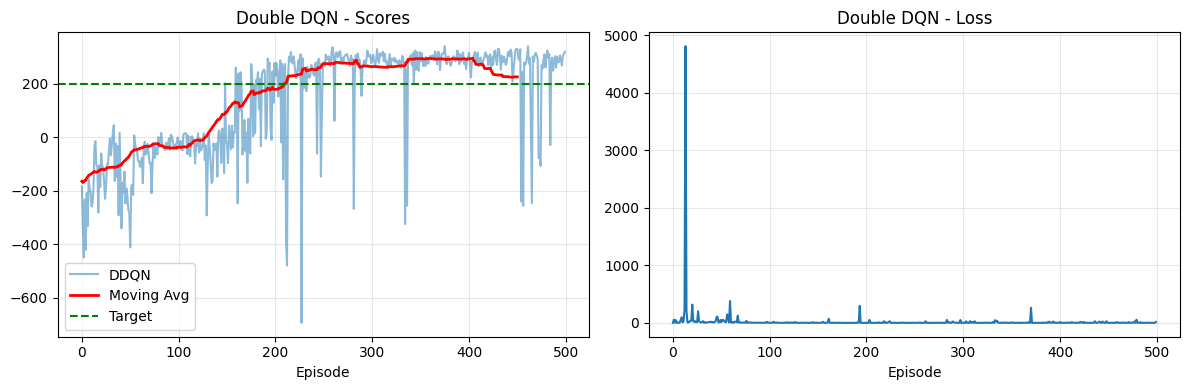


DDQN Final Avg Score (last 50): 224.6


In [33]:
print("="*60)
print("TRAINING DOUBLE DQN ON LUNAR LANDER")
print("="*60)

# Reset seeds for fair comparison
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

env2 = gym.make('LunarLander-v3')
state_dim = env2.observation_space.shape[0]
action_dim = env2.action_space.n

# Create DDQN agent
ddqn_agent = DDQNAgent(state_dim, action_dim)

# Train
ddqn_scores, ddqn_losses = train_dqn(env2, ddqn_agent, num_episodes=500, max_steps=1000)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Video
render_env = gym.make('LunarLander-v3', render_mode='rgb_array')
save_agent_video(render_env, ddqn_agent, filename="ddqn.mp4")
video_ddqn = "ddqn.mp4"

axes[0].plot(ddqn_scores, alpha=0.5, label='DDQN')
axes[0].plot(np.convolve(ddqn_scores, np.ones(50)/50, mode='valid'), 'r-', linewidth=2, label='Moving Avg')
axes[0].axhline(y=200, color='g', linestyle='--', label='Target')
axes[0].set_title('Double DQN - Scores')
axes[0].set_xlabel('Episode')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ddqn_losses)
axes[1].set_title('Double DQN - Loss')
axes[1].set_xlabel('Episode')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDDQN Final Avg Score (last 50): {np.mean(ddqn_scores[-50:]):.1f}")

# Dueling DQN

### DuelingQNetwork — Splitting Value and Advantage

Instead of estimating $Q(s,a)$ directly, we break it into two parts:


- **$V(s)$** = How good is it to be in this state? (regardless of action)
- **$A(s,a)$** = How much better is action $a$ compared to other actions?

### Why Is This Better?
Imagine you're watching a movie:
- Some scenes are exciting regardless of what happens → **$V(s)$** is high
- The specific action matters more in tense scenes → **$A(s,a)$** carries more weight

By separating them, the network can learn **$V(s)$** directly without averaging across all actions.



### The Formula
We don't use $Q = V + A$ directly. Instead:

$$ Q(s,a) = V(s) + A(s,a) - mean(A(s,:))$$

In [22]:
# =============================================================================
# Dueling DQN
# Architecture that separates value and advantage estimation
# =============================================================================
class DuelingQNetwork(nn.Module):
    """
    Dueling DQN separates the value function into two streams:
    
    Q(s,a) = V(s) + A(s,a)
    
    - V(s): Value of being in state s
    - A(s,a): Advantage of taking action a
    
    This allows the network to learn which states are valuable
    without needing to learn the effect of each action.
    """
    
    def __init__(self, state_dim: int, action_dim: int):
        super(DuelingQNetwork, self).__init__()
        self.action_dim = action_dim
        
        # Shared feature extractor
        self.features = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU()
        )
        
        # Value stream: V(s)
        self.value_stream = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        
        # Advantage stream: A(s,a)
        self.advantage_stream = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
    
    def forward(self, x):
        features = self.features(x)
        
        # Get value and advantage
        value = self.value_stream(features) # V(s)
        advantage = self.advantage_stream(features) # A(s,a)
        
        # Combine: Q(s,a) = V(s) + A(s,a) - mean(A(s,:))
        # Subtracting mean stabilizes training
        q_values = value + advantage - advantage.mean(dim=1, keepdim=True)
        
        return q_values

In [23]:
class DuelingDQNAgent:
    """
    Dueling DQN uses the dueling network architecture.
    The update rule is the same as DDQN, 
    but the network architecture is different.
    """
    
    def __init__(self, state_dim: int, action_dim: int):
        # TODO
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.batch_size = 64
        self.target_update_freq = 60
        self.action_dim = action_dim
        
        # Networks (Dueling architecture)
        self.q_network = DuelingQNetwork(state_dim, action_dim).to(device)
        self.target_network = DuelingQNetwork(state_dim, action_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=0.0005)
        self.memory = ReplayBuffer(capacity=100000)
        self.steps = 0
    
    def select_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                q_values = self.q_network(state_tensor)
            return q_values.argmax().item()
    
    def store_transition(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)
    
    def update(self):

        if len(self.memory) < self.batch_size:
            return None
        
        batch = self.memory.sample(self.batch_size)
        
        states = torch.FloatTensor(np.array([t.state for t in batch])).to(device)
        actions = torch.LongTensor(np.array([t.action for t in batch])).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(np.array([t.reward for t in batch])).to(device)
        next_states = torch.FloatTensor(np.array([t.next_state for t in batch])).to(device)
        dones = torch.FloatTensor(np.array([t.done for t in batch])).to(device)
        
        # Current Q values
        current_q = self.q_network(states).gather(1, actions).squeeze()
        
        # Target Q values
        with torch.no_grad():
            next_actions = self.q_network(next_states).argmax(1, keepdim=True) 
            next_q = self.target_network(next_states).gather(1, next_actions).squeeze()
            target_q = rewards + (1 - dones) * self.gamma * next_q
        
        # Compute loss
        loss = nn.MSELoss()(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update target network
        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
        
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
        return loss.item()

TRAINING DUELING DQN ON LUNAR LANDER
Episode 50/500 | Score: -44.4 | Avg: -125.9 | ε: 0.010
Episode 100/500 | Score: -8.6 | Avg: -52.7 | ε: 0.010
Episode 150/500 | Score: -26.3 | Avg: -33.0 | ε: 0.010
Episode 200/500 | Score: 64.8 | Avg: -17.6 | ε: 0.010
Episode 250/500 | Score: 250.8 | Avg: 102.3 | ε: 0.010
Episode 300/500 | Score: 240.0 | Avg: 244.2 | ε: 0.010
Episode 350/500 | Score: 45.2 | Avg: 242.3 | ε: 0.010
Episode 400/500 | Score: 273.3 | Avg: 217.3 | ε: 0.010
Episode 450/500 | Score: 282.8 | Avg: 246.6 | ε: 0.010
Episode 500/500 | Score: 289.9 | Avg: 273.5 | ε: 0.010


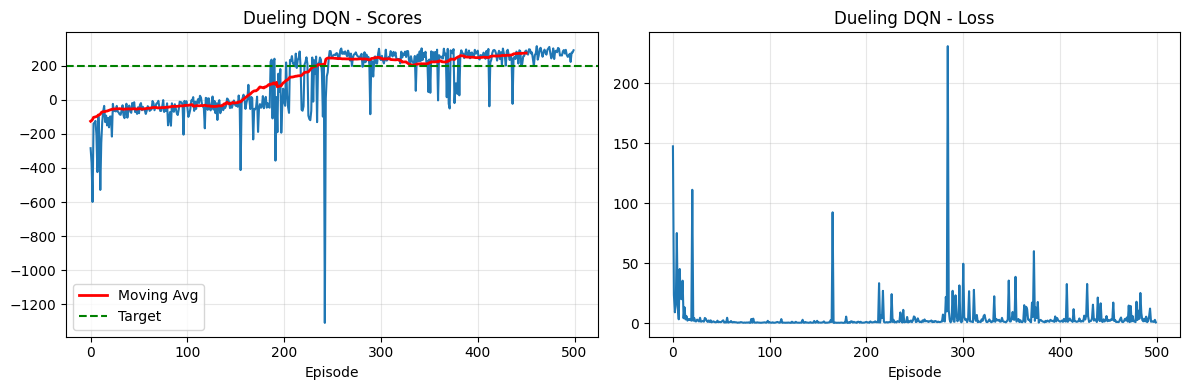


Dueling DQN Final Avg Score (last 50): 273.5


In [24]:
print("="*60)
print("TRAINING DUELING DQN ON LUNAR LANDER")
print("="*60)

env3 = gym.make('LunarLander-v3')
state_dim = env3.observation_space.shape[0]
action_dim = env3.action_space.n

# Create agent
dueling_agent = DuelingDQNAgent(state_dim, action_dim)

# Train
dueling_scores, dueling_losses = train_dqn(env3, dueling_agent, num_episodes=500, max_steps=1000)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Video
render_env = gym.make('LunarLander-v3', render_mode='rgb_array')
save_agent_video(render_env, dueling_agent, filename="duelingdqn.mp4")
video_duelingdqn = "duelingdqn.mp4"

axes[0].plot(dueling_scores)
axes[0].plot(np.convolve(dueling_scores, np.ones(50)/50, mode='valid'), 'r-', linewidth=2, label='Moving Avg')
axes[0].axhline(y=200, color='g', linestyle='--', label='Target')
axes[0].set_title('Dueling DQN - Scores')
axes[0].set_xlabel('Episode')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(dueling_losses)
axes[1].set_title('Dueling DQN - Loss')
axes[1].set_xlabel('Episode')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDueling DQN Final Avg Score (last 50): {np.mean(dueling_scores[-50:]):.1f}")

show_video(video_duelingdqn, width=600)

# Prioritized Experience Replay (PER)

### SumTree — The Priority Organizer

### Why Do We Need It?
Regular replay buffer picks experiences **randomly**.
But some experiences teach us more than others!

Experiences with **high TD error** (big surprise) are more valuable.
We want to pick those more often.

### How Does SumTree Work?
Think of it like a **binary tree** where:
- Each **leaf** = one experience with a priority score
- Each **internal node** = sum of its children


In [18]:
# =============================================================================
# Prioritized Experience Replay (PER) DQN
# Based on "Prioritized Experience Replay" (Schaul et al., 2016)
# =============================================================================

class SumTree:
    """
    Sum Tree data structure for efficient prioritized sampling.
    
    Stores priorities in a binary tree where:
    - Parent = sum of children
    - Leaf nodes = individual priorities
    
    Allows O(log n) sampling and O(1) priority updates.
    """
    
    def __init__(self, capacity: int):
        # TODO
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1) # Binary tree storage
        self.data = [None] * capacity # Actual transitions
        self.write_idx = 0 # Current write position
        self.size = 0 # Number of stored items
    
    def add(self, priority: float, transition: Transition):
        """Add new experience with given priority"""
        idx = self.write_idx + self.capacity - 1  # Leaf node index
        
        self.data[self.write_idx] = transition
        self.update(idx, priority)
        
        self.write_idx = (self.write_idx + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)
    
    def update(self, idx: int, priority: float):
        """Update priority of a leaf node"""
        change = priority - self.tree[idx]
        self.tree[idx] = priority
        
        # Propagate change up the tree
        while idx > 0:
            idx = (idx - 1) // 2
            self.tree[idx] += change
    
    def sample(self, batch_size: int) -> list:
        """Sample batch based on priorities (higher priority = more likely)"""
        batch = []
        segment = self.tree[0] / batch_size # Total priority / batch_size
        indices = []
        
        for i in range(batch_size):
            a = segment * i
            b = segment * (i + 1)
            
            # Random value in segment
            r = np.random.uniform(a, b)
            
            # Find leaf containing r
            idx = self._find_leaf(0, r)
            indices.append(idx)
            batch.append(self.data[idx - self.capacity + 1])
        
        return batch, indices
    
    def _find_leaf(self, idx: int, r: float) -> int:
        """Find leaf node containing priority value r"""
        left = 2 * idx + 1
        right = left + 1
        
        if left >= len(self.tree):
            return idx
        
        if r <= self.tree[left]:
            return self._find_leaf(left, r)
        else:
            return self._find_leaf(right, r - self.tree[left])
    
    def __len__(self):
        return self.size

### The Problem with Uniform Sampling
Regular buffer treats all experiences equally.
But if you already know something well, reviewing it is a waste of time!

### The Solution: Priority-Based Sampling
We sample experiences with probability proportional to their TD error:

+ ${P}(\text{experience}) \propto  |\text{TD error}|^\alpha $

- $\alpha = 0 \to$ uniform sampling (like regular buffer)
- $\alpha = 1 \to$ full prioritization (only important experiences)

### Importance Sampling (IS) Weights
Prioritization changes the distribution → introduces **bias**.
We fix this with IS weights:
+ $w = (N × \mathbb{P}(i))^{-\beta}$

- $\beta = 0 \to$ no correction (fast but biased)
- $\beta = 1 \to$ full correction (unbiased but higher variance)


In [19]:
class PrioritizedReplayBuffer:
    """
    Prioritized Experience Replay Buffer
    
    Key ideas:
    - Not all experiences are equally important
    - Sample experiences with higher TD-error more often
    - Use importance sampling weights to correct bias
    
    Priority = |TD_error|^α + ε
    - α: how much prioritization (0 = uniform, 1 = full)
    - ε: small constant to ensure non-zero probability
    """
    
    def __init__(self, capacity: int = 100, alpha: float = None, beta: float = None):
        self.capacity = capacity
        self.alpha = alpha # Priority exponent
        self.beta = beta # Importance sampling exponent
        self.beta_increment = 0.001 # Beta grows towards 1
        self.epsilon = 1e-6 # Small constant
        
        self.tree = SumTree(capacity)
        self.max_priority = 1.0  # For new experiences
    
    def push(self, *args):
        """Add new experience with max priority (so it's sampled soon)"""
        transition = Transition(*args)
        priority = self.max_priority ** self.alpha
        self.tree.add(priority, transition)
    
    def sample(self, batch_size: int) -> tuple:
        """Sample batch with priorities and compute IS weights"""
        batch, indices = self.tree.sample(batch_size)
        
        # Calculate priorities and IS weights
        priorities = []
        for idx in indices:
            priorities.append(self.tree.tree[idx])
        
        # Compute importance sampling weights
        priorities = np.array([self.tree.tree[idx] for idx in indices])
        probs = priorities / self.tree.tree[0]
        weights = (self.tree.size * probs) ** (-self.beta)
        weights = weights / weights.max()  # Normalize
        weights_tensor = torch.FloatTensor(weights).to(device)
        
        # Transpose batch
        states = torch.FloatTensor(np.array([t.state for t in batch])).to(device)
        actions = torch.LongTensor(np.array([t.action for t in batch])).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(np.array([t.reward for t in batch])).to(device)
        next_states = torch.FloatTensor(np.array([t.next_state for t in batch])).to(device)
        dones = torch.FloatTensor(np.array([t.done for t in batch])).to(device)
        
        return states, actions, rewards, next_states, dones, weights_tensor, indices
    
    def update_priorities(self, indices: list, td_errors: np.ndarray):
        """Update priorities based on TD errors"""
        for idx, td_error in zip(indices, td_errors):
            priority = (np.abs(td_error) + self.epsilon) ** self.alpha
            self.tree.update(idx, priority)
            self.max_priority = max(self.max_priority, priority)
    
    def __len__(self):
        return len(self.tree)

In [20]:
class PERDQNAgent:
    """
    DQN with Prioritized Experience Replay
    
    Differences from DDQN:
    - Uses SumTree for efficient prioritized sampling
    - Computes importance sampling weights
    - Updates priorities after each batch
    """
    
    def __init__(self, state_dim: int, action_dim: int):
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.batch_size = 64
        self.target_update_freq = 60
        self.action_dim = action_dim
        
        # PER parameters
        self.alpha = 0.6
        self.beta = 0.4
        self.beta_increment = 0.001
        
        # Networks
        self.q_network = QNetwork(state_dim, action_dim).to(device)
        self.target_network = QNetwork(state_dim, action_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=0.0005)
        
        # Prioritized Replay Buffer
        self.memory = PrioritizedReplayBuffer(capacity=100000, alpha=self.alpha, beta=self.beta)
        self.steps = 0
    
    def select_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                q_values = self.q_network(state_tensor)
            return q_values.argmax().item()
    
    def store_transition(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)
    
    def update(self):
        """PER DQN update with importance sampling"""
        if len(self.memory) < self.batch_size:
            return None
        
        # Sample from prioritized buffer
        states, actions, rewards, next_states, dones, weights, indices = self.memory.sample(self.batch_size)

        # Current Q values
        current_q = self.q_network(states).gather(1, actions).squeeze()
        
        # Target Q values (Double DQN style)
        with torch.no_grad():
            next_actions = self.q_network(next_states).argmax(1, keepdim=True)
            next_q = self.target_network(next_states).gather(1, next_actions).squeeze()
            target_q = rewards + (1 - dones) * self.gamma * next_q
        
        # Compute TD errors for priority update
        td_errors = (current_q.detach() - target_q).abs().cpu().numpy()
        
        # Weighted loss (importance sampling)
        loss = (weights * (current_q - target_q).pow(2)).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update priorities (using random indices for simplicity)
        # In full implementation, you'd track actual indices
        indices = [int(idx) for idx in indices]
        self.memory.update_priorities(indices, td_errors)
        
        # Increment beta (towards 1.0)
        self.beta = min(1.0, self.beta + self.beta_increment)
        
        # Update target network
        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
        
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
        return loss.item()

TRAINING PER DQN ON LUNAR LANDER
Episode 50/500 | Score: 9.2 | Avg: -98.2 | ε: 0.010
Episode 100/500 | Score: 0.6 | Avg: -35.1 | ε: 0.010
Episode 150/500 | Score: -30.4 | Avg: -45.8 | ε: 0.010
Episode 200/500 | Score: 250.0 | Avg: 114.3 | ε: 0.010
Episode 250/500 | Score: 241.0 | Avg: 209.5 | ε: 0.010
Episode 300/500 | Score: 245.6 | Avg: 207.1 | ε: 0.010
Episode 350/500 | Score: 282.9 | Avg: 253.2 | ε: 0.010
Episode 400/500 | Score: 270.2 | Avg: 260.7 | ε: 0.010
Episode 450/500 | Score: 300.8 | Avg: 259.9 | ε: 0.010
Episode 500/500 | Score: 292.5 | Avg: 225.3 | ε: 0.010


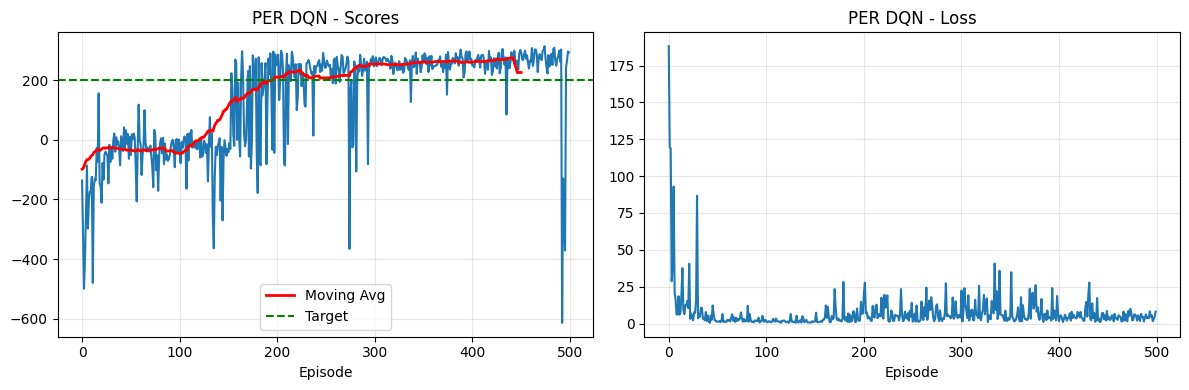


PER DQN Final Avg Score (last 50): 225.3


In [21]:
print("="*60)
print("TRAINING PER DQN ON LUNAR LANDER")
print("="*60)

# Reset seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

env4 = gym.make('LunarLander-v3')

per_agent = PERDQNAgent(state_dim, action_dim)
per_scores, per_losses = train_dqn(env4, per_agent, num_episodes=500, max_steps=1000)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Video
render_env = gym.make('LunarLander-v3', render_mode='rgb_array')
save_agent_video(render_env, per_agent, filename="perdqn.mp4")
video_perdqn = "perdqn.mp4"


axes[0].plot(per_scores)
axes[0].plot(np.convolve(per_scores, np.ones(50)/50, mode='valid'), 'r-', linewidth=2, label='Moving Avg')
axes[0].axhline(y=200, color='g', linestyle='--', label='Target')
axes[0].set_title('PER DQN - Scores')
axes[0].set_xlabel('Episode')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(per_losses)
axes[1].set_title('PER DQN - Loss')
axes[1].set_xlabel('Episode')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPER DQN Final Avg Score (last 50): {np.mean(per_scores[-50:]):.1f}")

show_video(video_perdqn, width=600)

# Half-Rainbow DQN (Double + Dueling + PER)

Rainbow DQN (Hessel et al., 2018) combined **6 different techniques**.
In this section we implement the 3 mentioned ones.


### Your Task
- Combine `DuelingQNetwork` architecture
- Use `PrioritizedReplayBuffer` for storage
- Implement Double DQN update logic
- Make sure priorities are updated after each learning step

In [28]:
# =============================================================================
# Double DQN + Dueling Architecture + Prioritized Experience Replay
# =============================================================================

class CombinedDQNAgent:
    """
    1. Double DQN - Reduces overestimation
    2. Dueling Network - Better value estimation
    3. Prioritized Experience Replay - Better sample efficiency
    
    This is the state-of-the-art DQN variant!
    """
    
    def __init__(self, state_dim: int, action_dim: int):
        # Hyperparameters
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.batch_size = 64
        self.target_update_freq = 60
        self.action_dim = action_dim
        
        # PER parameters
        self.alpha = 0.6
        self.beta = 0.4
        self.beta_increment = 0.001
        
        # Networks (Dueling architecture)
        self.q_network = DuelingQNetwork(state_dim, action_dim).to(device)
        self.target_network = DuelingQNetwork(state_dim, action_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=0.0005)
        
        # Prioritized Replay Buffer
        self.memory = PrioritizedReplayBuffer(capacity=100000, alpha=self.alpha, beta=self.beta)
        self.steps = 0
    
    def select_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            with torch.no_grad():
                q_values = self.q_network(state_tensor)
            return q_values.argmax().item()
    
    def store_transition(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)
    
    def update(self):
        """Combined update: Double DQN + Dueling + PER"""
        if len(self.memory) < self.batch_size:
            return None
        
        # Sample from prioritized buffer
        states, actions, rewards, next_states, dones, weights, indices = self.memory.sample(self.batch_size)
        
        # Current Q values (Dueling architecture)
        current_q = self.q_network(states).gather(1, actions).squeeze()
        
        # Target Q values (Double DQN)
        with torch.no_grad():
            # Use online network to select action
            next_actions = self.q_network(next_states).argmax(1, keepdim=True)
            # Use target network to evaluate
            next_q = self.target_network(next_states).gather(1, next_actions).squeeze()  
            target_q = rewards + (1 - dones) * self.gamma * next_q 

        # TD errors for PER
        td_errors = (current_q.detach() - target_q).abs().cpu().numpy()
        self.memory.update_priorities(indices, td_errors)
        
        # Weighted loss with importance sampling
        loss = (weights * (current_q - target_q).pow(2)).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update beta
        self.beta = min(1.0, self.beta + self.beta_increment)
        
        # Update target network
        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
        
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        
        return loss.item()

TRAINING HALF RAINBOW DQN (Double + Dueling + PER)
Episode 50/500 | Score: -402.7 | Avg: -139.3 | ε: 0.010
Episode 100/500 | Score: -105.1 | Avg: -97.6 | ε: 0.010
Episode 150/500 | Score: 6.5 | Avg: -11.7 | ε: 0.010
Episode 200/500 | Score: 209.3 | Avg: 170.1 | ε: 0.010
Episode 250/500 | Score: -528.1 | Avg: 108.2 | ε: 0.010
Episode 300/500 | Score: 243.2 | Avg: 173.1 | ε: 0.010
Episode 350/500 | Score: 298.6 | Avg: 185.6 | ε: 0.010
Episode 400/500 | Score: 247.4 | Avg: 157.2 | ε: 0.010
Episode 450/500 | Score: 286.3 | Avg: 211.6 | ε: 0.010
Episode 500/500 | Score: 100.0 | Avg: 232.2 | ε: 0.010


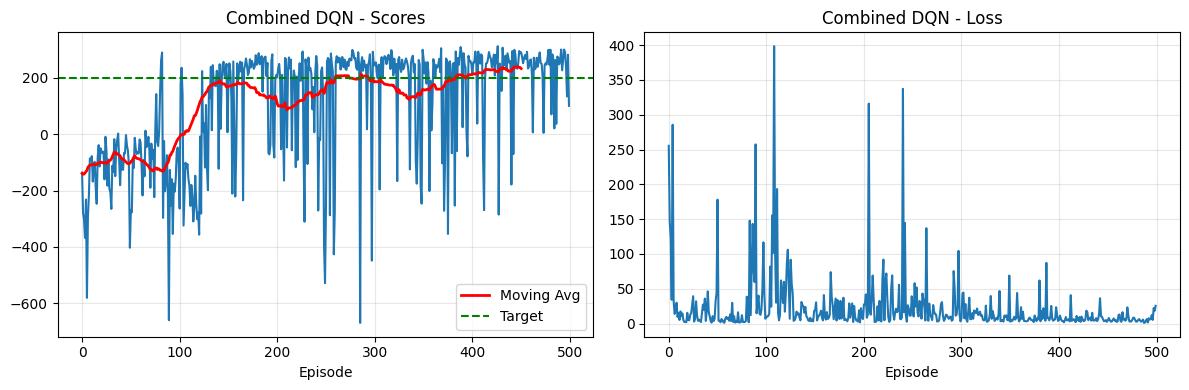


Combined DQN Final Avg Score (last 50): 232.2


In [29]:
print("="*60)
print("TRAINING HALF RAINBOW DQN (Double + Dueling + PER)")
print("="*60)

# Reset seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

env5 = gym.make('LunarLander-v3')

combined_agent = CombinedDQNAgent(state_dim, action_dim) 
combined_scores, combined_losses = train_dqn(env5, combined_agent, num_episodes=500, max_steps=1000)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Video
render_env = gym.make('LunarLander-v3', render_mode='rgb_array')
save_agent_video(render_env, combined_agent, filename="halfrainbow.mp4")
video_halfrainbow = "halfrainbow.mp4"

axes[0].plot(combined_scores)
axes[0].plot(np.convolve(combined_scores, np.ones(50)/50, mode='valid'), 'r-', linewidth=2, label='Moving Avg')
axes[0].axhline(y=200, color='g', linestyle='--', label='Target')
axes[0].set_title('Combined DQN - Scores')
axes[0].set_xlabel('Episode')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(combined_losses)
axes[1].set_title('Combined DQN - Loss')
axes[1].set_xlabel('Episode')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCombined DQN Final Avg Score (last 50): {np.mean(combined_scores[-50:]):.1f}")

show_video(video_halfrainbow, width=600)

# Last Task: Final Comparison - All Methods


FINAL SUMMARY - ALL METHODS COMPARISON
Method               Avg Score (last 50)       Status         
----------------------------------------------------------------------
DQN                  219.4                     Basic          
Double DQN           224.6                     Reduced overestimation
Dueling DQN          273.5                     Better V(s) estimation
PER DQN              225.3                     Better sampling
Combined             232.2                     All techniques 
Target Score: 200 (solved)


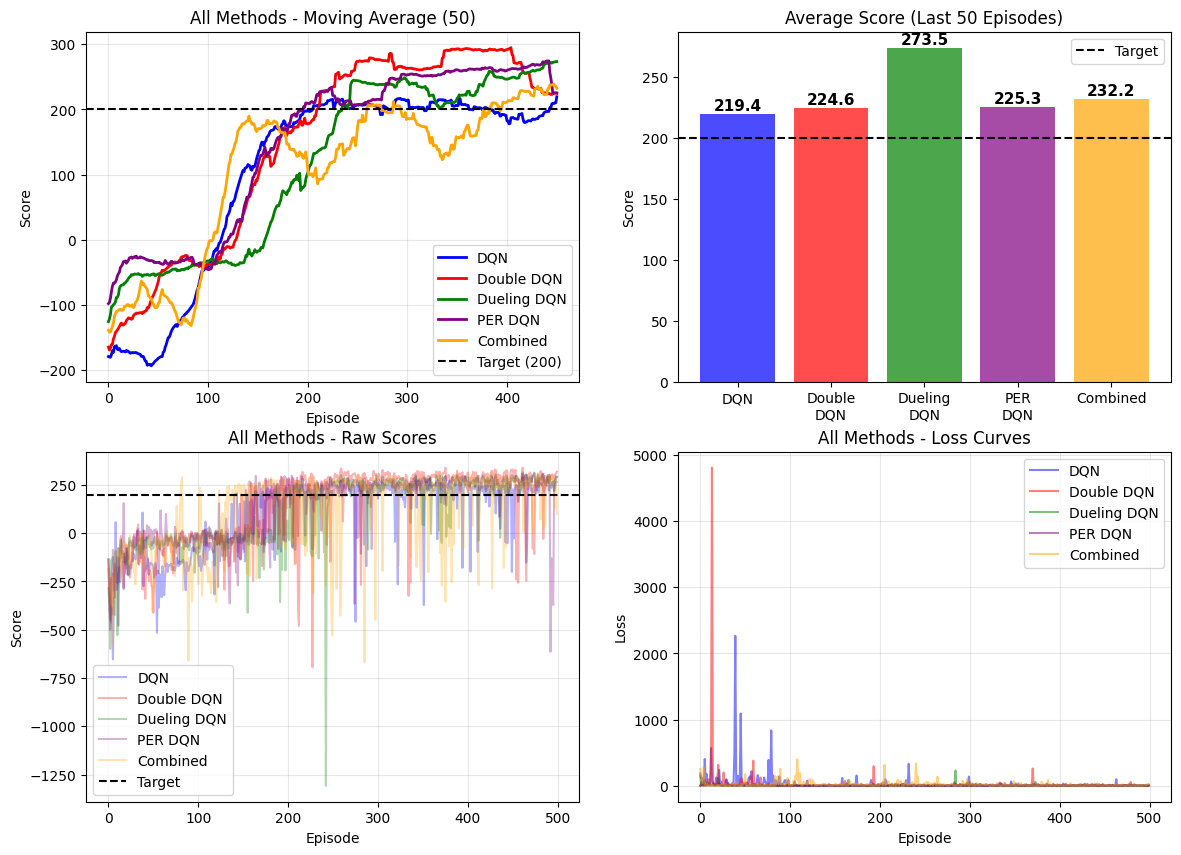

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

window = 50

# Calculate moving averages
dqn_ma = np.convolve(dqn_scores, np.ones(window)/window, mode='valid')
ddqn_ma = np.convolve(ddqn_scores, np.ones(window)/window, mode='valid')
dueling_ma = np.convolve(dueling_scores, np.ones(window)/window, mode='valid')
per_ma = np.convolve(per_scores, np.ones(window)/window, mode='valid')
combined_ma = np.convolve(combined_scores, np.ones(window)/window, mode='valid')

# Plot 1: All moving averages
axes[0, 0].plot(dqn_ma, color='blue', linewidth=2, label='DQN')
axes[0, 0].plot(ddqn_ma, color='red', linewidth=2, label='Double DQN')
axes[0, 0].plot(dueling_ma, color='green', linewidth=2, label='Dueling DQN')
axes[0, 0].plot(per_ma, color='purple', linewidth=2, label='PER DQN')
axes[0, 0].plot(combined_ma, color='orange', linewidth=2, label='Combined')
axes[0, 0].axhline(y=200, color='black', linestyle='--', label='Target (200)')
axes[0, 0].set_title('All Methods - Moving Average (50)')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Score')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Final scores bar chart
labels = ['DQN', 'Double\nDQN', 'Dueling\nDQN', 'PER\nDQN', 'Combined']
final_scores = [
    np.mean(dqn_scores[-50:]),
    np.mean(ddqn_scores[-50:]),
    np.mean(dueling_scores[-50:]),
    np.mean(per_scores[-50:]),
    np.mean(combined_scores[-50:])
]
colors = ['blue', 'red', 'green', 'purple', 'orange']

bars = axes[0, 1].bar(labels, final_scores, color=colors, alpha=0.7)
axes[0, 1].axhline(y=200, color='black', linestyle='--', label='Target')
axes[0, 1].set_title('Average Score (Last 50 Episodes)')
axes[0, 1].set_ylabel('Score')
axes[0, 1].legend()

for bar, score in zip(bars, final_scores):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
                    f'{score:.1f}', ha='center', fontsize=11, fontweight='bold')

# Plot 3: Learning curves (bottom-left)
axes[1, 0].plot(dqn_scores, alpha=0.3, color='blue', label='DQN')
axes[1, 0].plot(ddqn_scores, alpha=0.3, color='red', label='Double DQN')
axes[1, 0].plot(dueling_scores, alpha=0.3, color='green', label='Dueling DQN')
axes[1, 0].plot(per_scores, alpha=0.3, color='purple', label='PER DQN')
axes[1, 0].plot(combined_scores, alpha=0.3, color='orange', label='Combined')
axes[1, 0].axhline(y=200, color='black', linestyle='--', label='Target')
axes[1, 0].set_title('All Methods - Raw Scores')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Loss curves (bottom-right)
axes[1, 1].plot(dqn_losses, alpha=0.5, color='blue', label='DQN')
axes[1, 1].plot(ddqn_losses, alpha=0.5, color='red', label='Double DQN')
axes[1, 1].plot(dueling_losses, alpha=0.5, color='green', label='Dueling DQN')
axes[1, 1].plot(per_losses, alpha=0.5, color='purple', label='PER DQN')
axes[1, 1].plot(combined_losses, alpha=0.5, color='orange', label='Combined')
axes[1, 1].set_title('All Methods - Loss Curves')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Final Summary
print("\n" + "="*70)
print("FINAL SUMMARY - ALL METHODS COMPARISON")
print("="*70)
print(f"{'Method':<20} {'Avg Score (last 50)':<25} {'Status':<15}")
print("-"*70)
print(f"{'DQN':<20} {np.mean(dqn_scores[-50:]):<25.1f} {'Basic':<15}")
print(f"{'Double DQN':<20} {np.mean(ddqn_scores[-50:]):<25.1f} {'Reduced overestimation':<15}")
print(f"{'Dueling DQN':<20} {np.mean(dueling_scores[-50:]):<25.1f} {'Better V(s) estimation':<15}")
print(f"{'PER DQN':<20} {np.mean(per_scores[-50:]):<25.1f} {'Better sampling':<15}")
print(f"{'Combined':<20} {np.mean(combined_scores[-50:]):<25.1f} {'All techniques':<15}")
print("="*70)
print(f"Target Score: 200 (solved)")